---
## 7 — Optimização Evolutiva

Pipeline de optimização com algoritmos evolutivos via `mealpy`.
Optimiza simultaneamente **hiperparâmetros** e **arquitectura** da CNN.

**Espaço de pesquisa (8 dimensões):**
- `learning_rate` — contínuo em [1e-4, 3e-2]
- `dropout_rate`  — contínuo em [0.0, 0.6]
- `batch_size`    — discreto: 32 / 64 / 128
- `n_blocks`      — discreto: 2 ou 3 blocos conv
- `filters`       — discreto: 32 / 64 / 128 (bloco 1)
- `filter_mult`   — multiplicador ×2 ou ×3 entre blocos
- `dense_units`   — discreto: 128 / 256 / 512
- `use_bn`        — booleano: com ou sem Batch Normalization

In [ ]:
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA ok  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU      : NAO ENCONTRADA — verifica --gpus all no docker run")

print()

# 2. Keras 3
import keras
print(f"Keras    : {keras.__version__}")
print(f"Backend  : {keras.backend.backend()}")

print()

# 3. Teste rapido: tensor na GPU
if torch.cuda.is_available():
    x = torch.randn(100, 100, device='cuda')
    y = torch.matmul(x, x)
    print(f"Teste GPU: OK (matmul 100x100 na {torch.cuda.get_device_name(0)})")


import os
os.environ['KERAS_BACKEND'] = 'torch'  # garante que está definido

import torch
import keras
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Backend: {keras.backend.backend()}")


PyTorch  : 2.10.0+cu128
CUDA ok  : True
GPU      : NVIDIA GeForce RTX 5060 Ti
VRAM     : 17.1 GB

Keras    : 3.12.1
Backend  : torch

Teste GPU: OK (matmul 100x100 na NVIDIA GeForce RTX 5060 Ti)
GPU: NVIDIA GeForce RTX 5060 Ti
Backend: torch


In [1]:
from Utils.optimizer import (
    run_optimization, compare_algorithms, train_best,
    plot_optimization_history, plot_algorithm_comparison,
    list_algorithms, train_best_from_json
)
from Utils.datasets import get_dataset



I0000 00:00:1774445197.479011   12899 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774445197.733633   12899 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774445199.675071   12899 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
list_algorithms()

# Carregar dados (reutiliza se já carregados)
data = get_dataset('cifar10')


  Available Algorithms
  PSO     Particle Swarm Optimization       — inspired by bird flocking
  GA      Genetic Algorithm                 — selection, crossover, mutation
  DE      Differential Evolution            — mutation by vector differences
  BSA     Backtracking Search Algorithm     — mutation with historical population memory
  GWO     Grey Wolf Optimizer               — wolf hierarchy

  CIFAR-10 loaded:
    Train      :  40000 samples
    Validation :  10000 samples
    Test       :  10000 samples
    Shape      : (32, 32, 3)
    Classes    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



  OPTIMIZACAO: PSO
  Iteracoes: 15  |  Populacao: 20  |  Total avaliacoes: 320  (init: 20  +  iter: 300)
  Epochs por avaliacao: 5
  Dimensoes do espaco: 8

  [   1] val_acc=0.0994  best=0.0994  lr=0.00861  blocks=3  filters=[32, 64, 128]  bn=True  dt=47s  t=47s
  [   2] val_acc=0.7528  best=0.7528  lr=0.00021  blocks=3  filters=[64, 128, 256]  bn=False  dt=53s  t=100s
  [   3] val_acc=0.5508  best=0.7528  lr=0.00244  blocks=3  filters=[128, 256, 512]  bn=True  dt=101s  t=201s
  [   4] val_acc=0.0979  best=0.7528  lr=0.00883  blocks=2  filters=[32, 64]  bn=True  dt=62s  t=264s
  [   5] val_acc=0.7178  best=0.7528  lr=0.00065  blocks=2  filters=[32, 64]  bn=True  dt=60s  t=324s
  [   6] val_acc=0.7372  best=0.7528  lr=0.00124  blocks=2  filters=[128, 256]  bn=False  dt=51s  t=376s
  [   7] val_acc=0.1040  best=0.7528  lr=0.00508  blocks=2  filters=[128, 256]  bn=True  dt=148s  t=523s
  [   8] val_acc=0.6999  best=0.7528  lr=0.00140  blocks=2  filters=[64, 128]  bn=True  dt=129s  t=652s

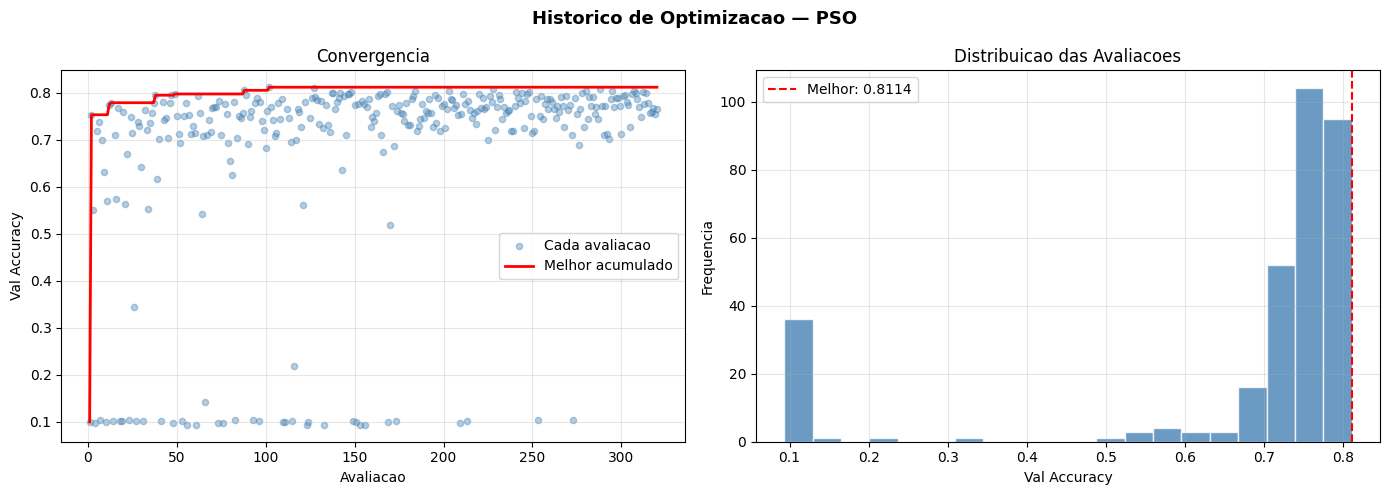

In [4]:
# ─────────────────────────────────────────────────────
# Configuração
# ─────────────────────────────────────────────────────
ALGORITHM   = 'PSO'   # ← mudar aqui: 'PSO','GA','DE','SA','WOA','GWO','ABC'
EVAL_EPOCHS = 5       # epochs por avaliação (rápido mas aproximado)
N_ITER      = 15      # número de iterações/gerações
POP_SIZE    = 20      # tamanho da população
# total de avaliações = N_ITER × POP_SIZE = 400
# ─────────────────────────────────────────────────────

best_config, opt_results = run_optimization(
    algorithm   = ALGORITHM,
    data        = data,
    eval_epochs = EVAL_EPOCHS,
    n_iter      = N_ITER,
    pop_size    = POP_SIZE,
)

plot_optimization_history(opt_results)


  OPTIMIZACAO: GA
  Iteracoes: 15  |  Populacao: 20  |  Total avaliacoes: 320  (init: 20  +  iter: 300)
  Epochs por avaliacao: 5
  Dimensoes do espaco: 8

  [   1] val_acc=0.5904  best=0.5904  lr=0.00861  blocks=3  filters=[32, 64, 128]  bn=True  dt=50s  t=50s
  [   2] val_acc=0.7549  best=0.7549  lr=0.00021  blocks=3  filters=[64, 128, 256]  bn=False  dt=58s  t=108s
  [   3] val_acc=0.0994  best=0.7549  lr=0.00244  blocks=3  filters=[128, 256, 512]  bn=True  dt=104s  t=212s
  [   4] val_acc=0.1030  best=0.7549  lr=0.00883  blocks=2  filters=[32, 64]  bn=True  dt=62s  t=274s
  [   5] val_acc=0.6735  best=0.7549  lr=0.00065  blocks=2  filters=[32, 64]  bn=True  dt=61s  t=334s
  [   6] val_acc=0.7097  best=0.7549  lr=0.00124  blocks=2  filters=[128, 256]  bn=False  dt=53s  t=387s
  [   7] val_acc=0.0933  best=0.7549  lr=0.00508  blocks=2  filters=[128, 256]  bn=True  dt=144s  t=531s
  [   8] val_acc=0.7183  best=0.7549  lr=0.00140  blocks=2  filters=[64, 128]  bn=True  dt=129s  t=660s


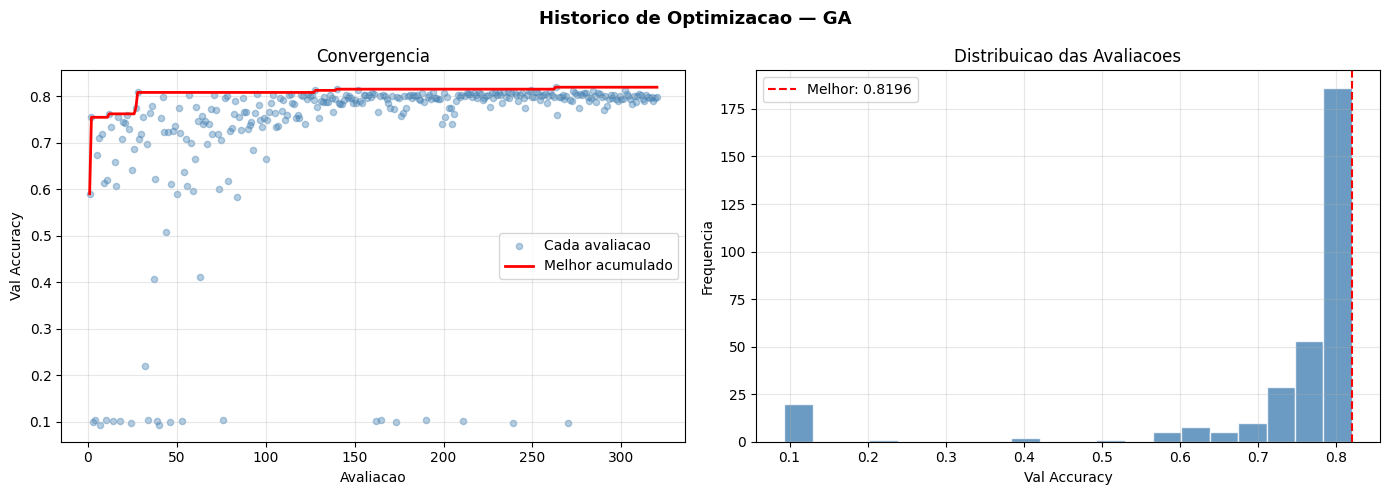

In [3]:
# ─────────────────────────────────────────────────────
# Configuração
# ─────────────────────────────────────────────────────
ALGORITHM   = 'GA'   # ← mudar aqui: 'PSO','GA','DE','SA','WOA','GWO','ABC'
EVAL_EPOCHS = 5       # epochs por avaliação (rápido mas aproximado)
N_ITER      = 15      # número de iterações/gerações
POP_SIZE    = 20      # tamanho da população
# total de avaliações = N_ITER × POP_SIZE = 400
# ─────────────────────────────────────────────────────

best_config, opt_results = run_optimization(
    algorithm   = ALGORITHM,
    data        = data,
    eval_epochs = EVAL_EPOCHS,
    n_iter      = N_ITER,
    pop_size    = POP_SIZE,
)

plot_optimization_history(opt_results)


  OPTIMIZACAO: DE
  Iteracoes: 15  |  Populacao: 20  |  Total avaliacoes: 320  (init: 20  +  iter: 300)
  Epochs por avaliacao: 5
  Dimensoes do espaco: 8

  [   1] val_acc=0.1017  best=0.1017  lr=0.00861  blocks=3  filters=[32, 64, 128]  bn=True  dt=48s  t=48s
  [   2] val_acc=0.7512  best=0.7512  lr=0.00021  blocks=3  filters=[64, 128, 256]  bn=False  dt=54s  t=102s
  [   3] val_acc=0.4319  best=0.7512  lr=0.00244  blocks=3  filters=[128, 256, 512]  bn=True  dt=102s  t=203s
  [   4] val_acc=0.0996  best=0.7512  lr=0.00883  blocks=2  filters=[32, 64]  bn=True  dt=64s  t=268s
  [   5] val_acc=0.7098  best=0.7512  lr=0.00065  blocks=2  filters=[32, 64]  bn=True  dt=63s  t=331s
  [   6] val_acc=0.7495  best=0.7512  lr=0.00124  blocks=2  filters=[128, 256]  bn=False  dt=52s  t=383s
  [   7] val_acc=0.0996  best=0.7512  lr=0.00508  blocks=2  filters=[128, 256]  bn=True  dt=155s  t=538s
  [   8] val_acc=0.6159  best=0.7512  lr=0.00140  blocks=2  filters=[64, 128]  bn=True  dt=126s  t=664s


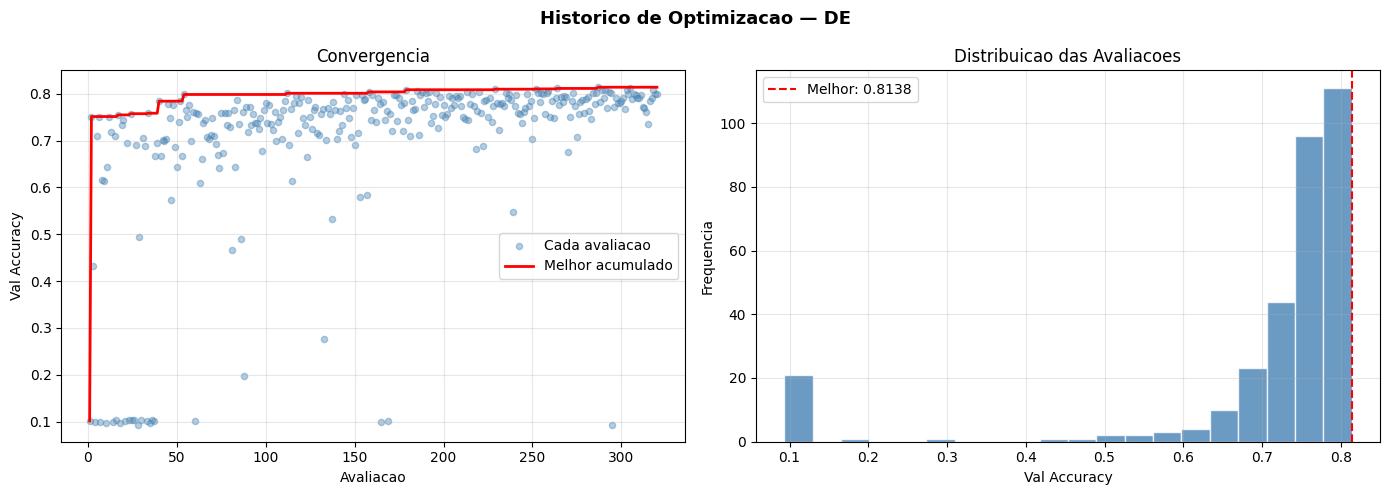

In [3]:
# ─────────────────────────────────────────────────────
# Configuração
# ─────────────────────────────────────────────────────
ALGORITHM   = 'DE'   # ← mudar aqui: 'PSO','GA','DE','SA','WOA','GWO','ABC'
EVAL_EPOCHS = 5       # epochs por avaliação (rápido mas aproximado)
N_ITER      = 15      # número de iterações/gerações
POP_SIZE    = 20      # tamanho da população
# total de avaliações = N_ITER × POP_SIZE = 400
# ─────────────────────────────────────────────────────

best_config, opt_results = run_optimization(
    algorithm   = ALGORITHM,
    data        = data,
    eval_epochs = EVAL_EPOCHS,
    n_iter      = N_ITER,
    pop_size    = POP_SIZE,
)

plot_optimization_history(opt_results)


  OPTIMIZATION: BSA
  Iterations: 15  |  Population: 20  |  Total evals: 320  (init: 20  +  iter: 300)
  Epochs per evaluation: 5
  Search space dimensions: 8

  [   1] val_acc=0.5176  best=0.5176  lr=0.00861  blocks=3  filters=[32, 64, 128]  bn=True  dt=51s  t=51s
  [   2] val_acc=0.7507  best=0.7507  lr=0.00021  blocks=3  filters=[64, 128, 256]  bn=False  dt=57s  t=107s
  [   3] val_acc=0.5888  best=0.7507  lr=0.00244  blocks=3  filters=[128, 256, 512]  bn=True  dt=102s  t=210s
  [   4] val_acc=0.0933  best=0.7507  lr=0.00883  blocks=2  filters=[32, 64]  bn=True  dt=65s  t=274s
  [   5] val_acc=0.7012  best=0.7507  lr=0.00065  blocks=2  filters=[32, 64]  bn=True  dt=65s  t=339s
  [   6] val_acc=0.7201  best=0.7507  lr=0.00124  blocks=2  filters=[128, 256]  bn=False  dt=53s  t=392s
  [   7] val_acc=0.0979  best=0.7507  lr=0.00508  blocks=2  filters=[128, 256]  bn=True  dt=149s  t=542s
  [   8] val_acc=0.7295  best=0.7507  lr=0.00140  blocks=2  filters=[64, 128]  bn=True  dt=128s  t=6

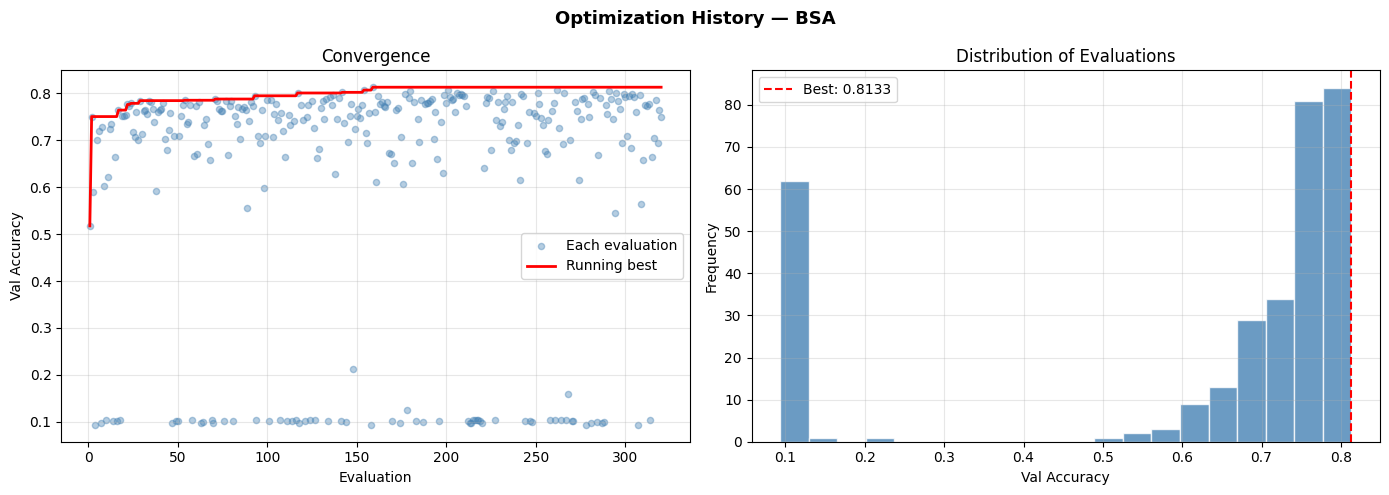

In [3]:
# ─────────────────────────────────────────────────────
# Configuração
# ─────────────────────────────────────────────────────
ALGORITHM   = 'BSA'   # ← mudar aqui: 'PSO','GA','DE','BSA', 'GWO'
EVAL_EPOCHS = 5       # epochs por avaliação (rápido mas aproximado)
N_ITER      = 15      # número de iterações/gerações
POP_SIZE    = 20      # tamanho da população
# total de avaliações = N_ITER × POP_SIZE = 400
# ─────────────────────────────────────────────────────

best_config, opt_results = run_optimization(
    algorithm   = ALGORITHM,
    data        = data,
    eval_epochs = EVAL_EPOCHS,
    n_iter      = N_ITER,
    pop_size    = POP_SIZE,
)

plot_optimization_history(opt_results)

In [3]:
pso_results = train_best_from_json('PSO', data, epochs=50, early_stopping_patience=5)
ga_results = train_best_from_json('GA', data, epochs=50, early_stopping_patience=5)
de_results = train_best_from_json('DE', data, epochs=50, early_stopping_patience=5)
bsa_results = train_best_from_json('BSA', data, epochs=50, early_stopping_patience=5)


  File loaded        : results/optimization/PSO_20260324_020936.json
  Algorithm          : PSO
  Best val_acc (opt) : 0.8114  (81.14%)

  FINAL TRAINING with optimized configuration
  learning_rate    0.000164
  dropout_rate     0.02
  batch_size       32
  n_blocks         3
  filters          [128, 256, 512]
  dense_units      512
  use_bn           True



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             

 Total params: 8,783,498 (33.51 MB)

 Trainable params: 8,779,914 (33.49 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,676,362 (25.47 MB)

 Trainable params: 6,676,362 (25.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.4178 - loss: 1.5759 - val_accuracy: 0.6082 - val_loss: 1.0966 - learning_rate: 2.8300e-04
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.6468 - loss: 1.0036 - val_accuracy: 0.7156 - val_loss: 0.8134 - learning_rate: 2.8300e-04
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.7417 - loss: 0.7403 - val_accuracy: 0.7522 - val_loss: 0.7001 - learning_rate: 2.8300e-04
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.8016 - loss: 0.5703 - val_accuracy: 0.7944 - val_loss: 0.6139 - learning_rate: 2.8300e-04
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.8467 - loss: 0.4381 - val_accuracy: 0.7962 - val_loss: 0.5978 - learning_rate: 2.8300e-04
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.8869 - loss: 0.3222 - val_accuracy: 0.8046 - val_loss: 0.6262 - learning_rate: 2.8300e-04
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━